In [43]:
import numpy as np
import matplotlib.pyplot as plt

In [44]:
# ================================
# DATA GENERATION
# ================================

def generate_dataset(n=10, noise_std=0.1, seed=42):
    np.random.seed(seed)
    x = np.linspace(0, 1, n)
    y = np.sin(2 * np.pi * x) + np.random.normal(0, noise_std, size=n)
    return x.reshape(-1, 1), y.reshape(-1, 1)

In [45]:

# ================================
# FEATURE ENGINEERING
# ================================

def build_polynomial_features(x, degree):
    # TODO: build Vandermonde-style matrix including bias term
    # x: (n,1) -> returns (n, degree+1) Vandermonde including bias column
    n = x.shape[0]
    X = np.ones((n, degree + 1))
    for d in range(1, degree + 1):
        X[:, d] = x[:, 0] ** d # fill in the d-th column with x^d 
    return X


In [46]:
# ================================
# NORMAL EQUATION
# ================================

def normal_equation(X, y):
    # TODO: implement (X^T X)^(-1) X^T y
    # closed form w = (X^T X)^{-1} X^T y
    XtX = X.T @ X # (d+1, n) @ (n, d+1) -> (d+1, d+1) @ means matrix multiplication and X.T is the transpose of X
    try:
        w = np.linalg.inv(XtX) @ X.T @ y # (d+1, d+1) @ (d+1, n) @ (n, 1) -> (d+1, 1)
    except np.linalg.LinAlgError:
        # fallback to pseudo-inverse if singular or numerically unstable
        w = np.linalg.pinv(XtX) @ X.T @ y # pinv is the pseudo-inverse which can handle singular matrices
    return w.reshape(-1, 1) # ensure w is a column vector

In [47]:

# ================================
# RIDGE REGRESSION
# ================================

def ridge_regression(X, y, lambda_):
    # TODO:
    # Implement (X^T X + λI)^(-1) X^T y
    # Do NOT regularize bias term
    XtX = X.T @ X
    d = XtX.shape[0] # number of features including bias
    I = np.eye(d)
    I[0, 0] = 0.0  # no regularization on bias
    A = XtX + lambda_ * I # (d, d) + λ * (d, d) -> (d, d)
    try:
        w = np.linalg.inv(A) @ X.T @ y # (d, d) @ (d, n) @ (n, 1) -> (d, 1)
    except np.linalg.LinAlgError:
        w = np.linalg.pinv(A) @ X.T @ y # fallback to pseudo-inverse if singular or numerically unstable
    return w.reshape(-1, 1) # ensure w is a column vector

In [48]:
# ================================
# ANALYSIS UTILITIES
# ================================

def compute_condition_number(X):
    return np.linalg.cond(X.T @ X)

def plot_results(x_train, y_train, x_plot, y_plot, title):
    plt.figure(figsize=(7,4))
    plt.scatter(x_train, y_train, label="Training Data")
    plt.plot(x_plot, y_plot, label="Model")
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.show()
    
def predict(w, x):
    degree = w.shape[0] - 1
    Xp = build_polynomial_features(x, degree)
    return Xp @ w
    


In [49]:
# ================================
# UNIT TESTS
# ================================

def test_polynomial_shape():
    x, _ = generate_dataset()
    X = build_polynomial_features(x, 20)
    assert X.shape[1] == 21, "Feature matrix should include bias + 20 degrees"

def test_normal_equation_solution():
    x, y = generate_dataset()
    X = build_polynomial_features(x, 2)
    w = normal_equation(X, y)
    assert w.shape[0] == X.shape[1], "Weight dimension mismatch"

def test_ridge_reduces_norm():
    x, y = generate_dataset()
    X = build_polynomial_features(x, 20)
    w_no_reg = normal_equation(X, y)
    w_reg = ridge_regression(X, y, 1.0)
    assert np.linalg.norm(w_reg) < np.linalg.norm(w_no_reg),         "Ridge should reduce coefficient magnitude"

def run_all_tests():
    test_polynomial_shape()
    test_normal_equation_solution()
    test_ridge_reduces_norm()
    print("All tests passed.")

All tests passed.
Task A1:
Feature matrix shape: (10, 21)


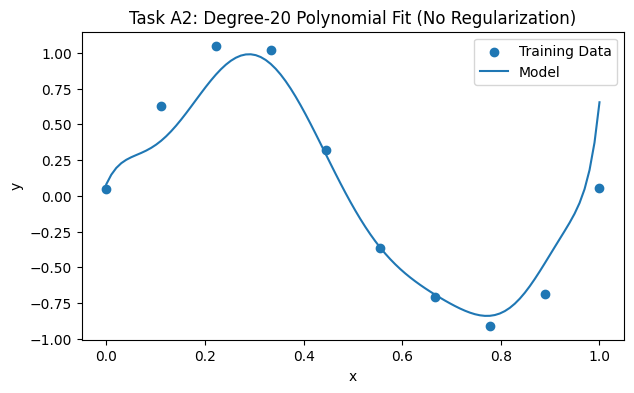


Task A3:
Coefficient magnitudes:
w[0] = 8.124769e-02
w[1] = 7.751930e+00
w[2] = 1.254280e+02
w[3] = 1.097959e+03
w[4] = 4.067398e+03
w[5] = 6.593741e+03
w[6] = 3.633758e+03
w[7] = 1.238782e+03
w[8] = 3.609257e+02
w[9] = 3.338371e+03
w[10] = 4.779841e+03
w[11] = 1.899989e+03
w[12] = 4.293710e+03
w[13] = 4.852725e+03
w[14] = 9.483800e+02
w[15] = 6.965217e+02
w[16] = 4.605251e+02
w[17] = 7.102331e+02
w[18] = 4.833307e+02
w[19] = 1.310403e+03
w[20] = 5.105143e+02
Condition number of (X^T X): 1.232e+18

Task B2: Ridge Regression Results

λ = 0
Coefficient norm ||w||₂: 12649.522106
Condition number: 1.232e+18


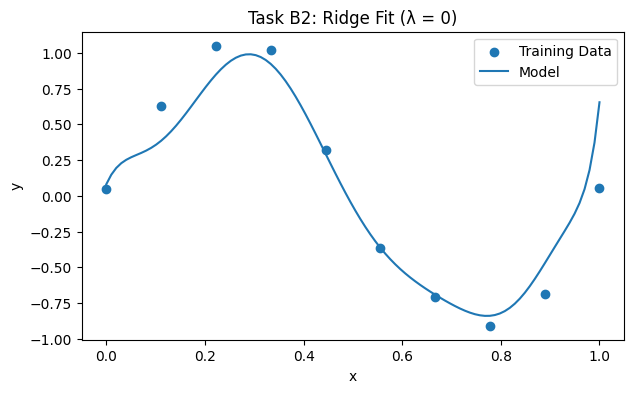


λ = 0.0001
Coefficient norm ||w||₂: 22.176040
Condition number: 2.807e+05


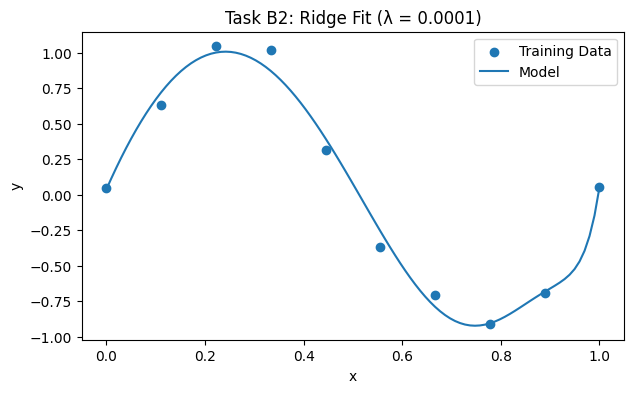


λ = 0.01
Coefficient norm ||w||₂: 5.697038
Condition number: 2.808e+03


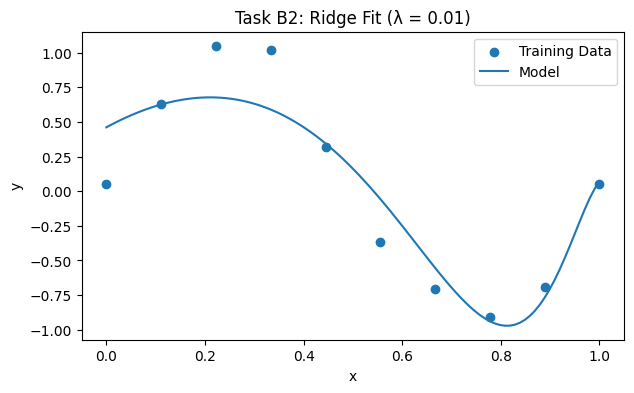


λ = 0.1
Coefficient norm ||w||₂: 1.791818
Condition number: 2.815e+02


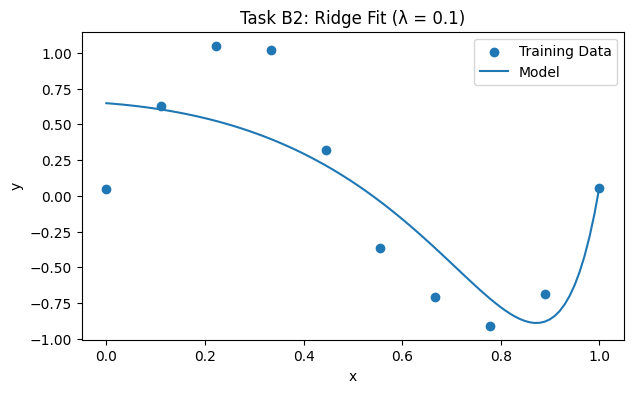


λ = 1
Coefficient norm ||w||₂: 0.964404
Condition number: 2.889e+01


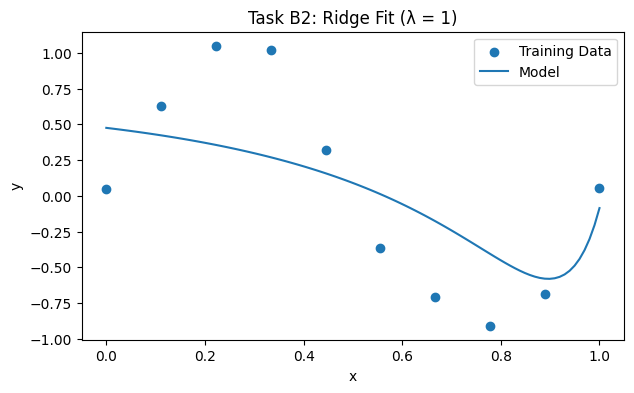

In [50]:
if __name__ == "__main__":
    run_all_tests()
    # ----------------
    # Generate dataset
    # ----------------
    x_train, y_train = generate_dataset()
    degree = 20
    X = build_polynomial_features(x_train, degree)

    # ==========================
    # Task A1: Verify dimensions
    # ==========================
    print("Task A1:")
    print("Feature matrix shape:", X.shape)  # (10, 21)

    # ==========================
    # Task A2: Normal Equation
    # ==========================
    w_no_reg = normal_equation(X, y_train)

    x_plot = np.linspace(0, 1, 100).reshape(-1, 1)
    y_plot = predict(w_no_reg, x_plot)

    plot_results(
        x_train, y_train,
        x_plot, y_plot,
        "Task A2: Degree-20 Polynomial Fit (No Regularization)"
    )

    # ==========================
    # Task A3: Stability Analysis
    # ==========================
    print("\nTask A3:")
    print("Coefficient magnitudes:")
    for i, coef in enumerate(np.abs(w_no_reg.flatten())):
        print(f"w[{i}] = {coef:.6e}")

    cond_no_reg = compute_condition_number(X)
    print("Condition number of (X^T X):", f"{cond_no_reg:.3e}")

    # ==========================
    # Task B1 & B2: Ridge Study
    # ==========================
    lambdas = [0, 1e-4, 1e-2, 1e-1, 1]

    print("\nTask B2: Ridge Regression Results")
    for lam in lambdas:
        w_ridge = ridge_regression(X, y_train, lam)
        y_ridge = predict(w_ridge, x_plot)

        # Condition number of regularized system
        XtX = X.T @ X
        I = np.eye(XtX.shape[0])
        I[0, 0] = 0.0
        cond_ridge = np.linalg.cond(XtX + lam * I)

        coef_norm = np.linalg.norm(w_ridge)

        print(f"\nλ = {lam}")
        print("Coefficient norm ||w||₂:", f"{coef_norm:.6f}")
        print("Condition number:", f"{cond_ridge:.3e}")

        plot_results(
            x_train, y_train,
            x_plot, y_ridge,
            f"Task B2: Ridge Fit (λ = {lam})"
        )